
# Problema - Dar cambio con monedas colombianas

## Laboratorio de Programación Dinámica

Una tienda necesita calcular la **menor cantidad de monedas** necesaria para entregar un cambio exacto.

Las monedas disponibles son:

```python
[50, 100, 200, 500, 1000]
```

La solución se desarrolla con **programación dinámica por tabulación**. La lista `dp` guarda los resultados de los subproblemas ya resueltos para reutilizarlos al calcular valores mayores.


In [ ]:


nombre = "Andrés Marín"
carnet = 1000112123




## 1) Descripción del problema

El usuario debe ingresar el valor del cambio que necesita entregar.

El programa debe encontrar la **cantidad mínima de monedas** necesaria para formar exactamente ese valor utilizando las denominaciones:

\[
50,\;100,\;200,\;500,\;1000
\]

Todos los valores válidos deben ser mayores o iguales a 50 y múltiplos de 50.

### Ejemplo

Si el usuario ingresa:

```text
1850
```

una forma óptima es:

```text
1000 + 500 + 200 + 100 + 50 = 1850
```

Por lo tanto, la cantidad mínima es:

```text
5 monedas
```

La programación dinámica permite resolver el problema guardando en `dp` la mejor respuesta encontrada para cada valor menor. Así, cuando se necesita una solución anterior, se consulta la memoria en lugar de comenzar nuevamente desde cero.



## 2) Requerimientos

### Requerimientos funcionales

1. Solicitar al usuario el valor del cambio.
2. Verificar que la entrada sea un número entero.
3. Verificar que el valor sea mayor o igual a 50.
4. Verificar que el valor sea múltiplo de 50.
5. Calcular la menor cantidad de monedas mediante programación dinámica.
6. Mostrar la cantidad mínima de monedas necesaria.
7. Permitir comprobar el algoritmo mediante pruebas.

### Requerimientos no funcionales

1. El código debe ser claro y sencillo.
2. La solución debe utilizar una tabla `dp` para almacenar soluciones parciales.
3. El programa debe controlar entradas inválidas sin finalizar inesperadamente.
4. Se debe analizar el tiempo de ejecución y el uso de memoria.



## 3) Historias de usuario

### Historia de usuario 1

**Como** usuario, **quiero** ingresar el valor del cambio **para** conocer cuántas monedas necesito.

**Criterios de aceptación:**
- El programa solicita el valor.
- Solo acepta números enteros.
- El valor debe ser mayor o igual a 50.
- El valor debe ser múltiplo de 50.

### Historia de usuario 2

**Como** usuario, **quiero** obtener la menor cantidad de monedas **para** entregar el cambio de forma eficiente.

**Criterios de aceptación:**
- Se utiliza programación dinámica.
- El resultado corresponde a una cantidad mínima.
- Para 1850 el resultado debe ser 5.

### Historia de usuario 3

**Como** usuario, **quiero** recibir mensajes cuando el valor sea incorrecto **para** saber cómo corregir la entrada.

**Criterios de aceptación:**
- Se rechazan valores menores de 50.
- Se rechazan valores que no sean múltiplos de 50.
- Se rechazan entradas que no sean números enteros.

### Historia de usuario 4

**Como** estudiante, **quiero** ejecutar pruebas automáticas **para** comprobar que el algoritmo produce los resultados esperados.

**Criterios de aceptación:**
- Se prueba el ejemplo de 1850.
- Se prueban otros valores.
- Las pruebas informan si el resultado obtenido coincide con el esperado.



## 5) Diagramas de secuencia

La secuencia principal comienza cuando el usuario ingresa el valor. Después de validarlo, `main()` llama a `calcular_cambio()`.

Dentro de la función se crea la tabla `dp`, se consultan las soluciones parciales almacenadas y finalmente se devuelve el resultado mínimo.

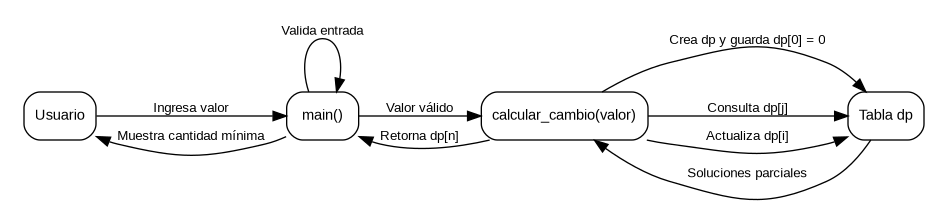



## 6) Diagramas de casos de uso

El usuario puede ingresar el valor del cambio, recibir el resultado y ejecutar pruebas. El cálculo del mínimo utiliza programación dinámica.

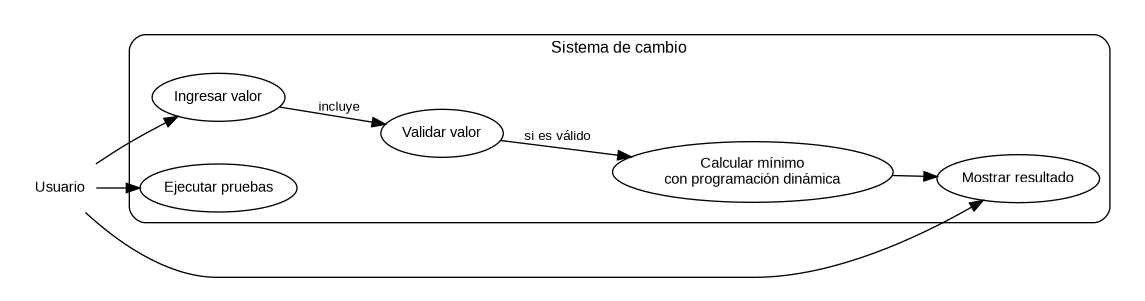



## 7) Análisis de complejidad

Para simplificar el problema se trabaja en unidades de 50.

Si el valor solicitado es, por ejemplo, 1850:

```text
n = 1850 // 50 = 37
```

Por lo tanto, `n` representa la cantidad de posiciones que deben analizarse para llegar al valor solicitado.

La parte principal del algoritmo tiene dos ciclos:

```python
for i in range(1, n + 1):
    for j in range(i):
```

El primer ciclo recorre los valores desde 1 hasta `n`.

El segundo ciclo recorre todos los subproblemas anteriores a `i`:

```text
cuando i = 1  -> 1 recorrido
cuando i = 2  -> 2 recorridos
cuando i = 3  -> 3 recorridos
...
cuando i = n  -> n recorridos
```

Por lo tanto, el número total de recorridos del ciclo interno es:

\[
1 + 2 + 3 + \cdots + n
\]

Esta suma equivale a:

\[
\frac{n(n+1)}{2}
\]

Al aumentar `n`, el término que más influye en el crecimiento es \(n^2\).

Por esta razón, la complejidad temporal del algoritmo es:

\[
O(n^2)
\]

### Mejor caso

Aunque el valor pueda formarse fácilmente, el programa sigue recorriendo los subproblemas anteriores para llenar la tabla.

Por lo tanto:

\[
O(n^2)
\]

### Peor caso

El programa realiza los mismos dos ciclos y revisa los subproblemas anteriores.

Por lo tanto:

\[
O(n^2)
\]

### Complejidad espacial

La memoria principal se guarda en:

```python
dp
```

La lista contiene `n + 1` posiciones, así que la memoria utilizada crece de forma lineal:

\[
O(n)
\]

En resumen:

| Recurso | Complejidad |
|---|---|
| Tiempo | \(O(n^2)\) |
| Memoria | \(O(n)\) |



## 8) Código funcional **[10 pts]**

La implementación utiliza una tabla llamada `dp`.

```text
dp[i]
```

guarda la cantidad mínima de monedas encontrada para formar el valor reducido `i`.

El valor inicial es:

```python
dp[0] = 0
```

porque para formar cero pesos se necesitan cero monedas.

Para calcular cada nuevo valor `i`, el algoritmo revisa todos los subvalores anteriores `j`. Si la diferencia `i - j` corresponde a una moneda disponible, se puede llegar a `i` utilizando la solución ya guardada en `dp[j]` y agregando una moneda.

Esta reutilización de soluciones anteriores es la memoria de la programación dinámica.


In [2]:

def calcular_cambio(valor):
    monedas = [1000, 500, 200, 100, 50]

    # Se trabaja en unidades de 50 para reducir el tamaño del problema.
    n = valor // 50
    monedas_reducidas = [moneda // 50 for moneda in monedas]

    # dp[i] guarda la cantidad mínima de monedas para formar i.
    dp = [float("inf")] * (n + 1)
    dp[0] = 0

    # Programación dinámica por tabulación.
    for i in range(1, n + 1):
        for j in range(i):
            moneda = i - j

            if moneda in monedas_reducidas:
                dp[i] = min(dp[i], dp[j] + 1)

    return dp[n]


def main():
    while True:
        try:
            valor = int(input("Digite el valor para hacer el cambio: "))

            if valor < 50:
                print("Ingrese un valor mayor o igual a 50")

            elif valor % 50 != 0:
                print("Ingrese un valor múltiplo de 50")

            else:
                break

        except ValueError:
            print("Ingrese un valor válido")

    cantidad = calcular_cambio(valor)
    print("Cantidad mínima de monedas igual a:", cantidad)



### Ejemplo de ejecución

En un notebook no se llama automáticamente a `main()` porque quedaría esperando una entrada del teclado.

Para utilizar el programa de forma interactiva se ejecuta:

```python
main()
```

A continuación se comprueba directamente el ejemplo solicitado.


In [3]:

valor = 1850
cantidad = calcular_cambio(valor)

print("Valor del cambio:", valor)
print("Cantidad mínima de monedas igual a:", cantidad)


Valor del cambio: 1850
Cantidad mínima de monedas igual a: 5



## 9) pruebas **[15 pts]**

Las pruebas se realizan con `assert`.

El procedimiento es:

1. Se envía un valor a `calcular_cambio()`.
2. La función calcula el resultado.
3. Se compara el resultado obtenido con el valor esperado.
4. Si ambos coinciden, la prueba pasa.
5. Si son diferentes, `assert` produce un error.

Esto permite comprobar el algoritmo automáticamente.


In [4]:

def test(valor, esperado):
    obtenido = calcular_cambio(valor)

    assert obtenido == esperado, (
        f"Para {valor} se obtuvo {obtenido}, "
        f"pero se esperaba {esperado}"
    )

    print(
        f"PRUEBA CORRECTA | "
        f"valor = {valor} | "
        f"resultado = {obtenido}"
    )



## Pruebas de enunciado

El caso principal es:

```text
Valor: 1850
Resultado esperado: 5 monedas
```


In [5]:
test(1850, 5)

PRUEBA CORRECTA | valor = 1850 | resultado = 5



## Pruebas propias

Se prueban diferentes valores para comprobar que el resultado continúe siendo correcto.


In [6]:

test(50, 1)
test(100, 1)
test(150, 2)
test(550, 2)
test(1000, 1)
test(1250, 3)
test(1750, 4)
test(2000, 2)
test(3450, 6)


PRUEBA CORRECTA | valor = 50 | resultado = 1
PRUEBA CORRECTA | valor = 100 | resultado = 1
PRUEBA CORRECTA | valor = 150 | resultado = 2
PRUEBA CORRECTA | valor = 550 | resultado = 2
PRUEBA CORRECTA | valor = 1000 | resultado = 1
PRUEBA CORRECTA | valor = 1250 | resultado = 3
PRUEBA CORRECTA | valor = 1750 | resultado = 4
PRUEBA CORRECTA | valor = 2000 | resultado = 2
PRUEBA CORRECTA | valor = 3450 | resultado = 6



## Pruebas de Desempeño

La prueba de desempeño mide cuánto tarda la función `calcular_cambio()` cuando aumenta el tamaño de la entrada.

### ¿Cómo se realiza la medición?

Para cada valor:

1. Se ejecuta una vez la función como calentamiento.
2. Después se ejecuta varias veces.
3. Antes de cada ejecución se guarda el tiempo inicial con `time.perf_counter()`.
4. Cuando termina la función se guarda el tiempo final.
5. El tiempo de ejecución se obtiene restando:

```text
tiempo final - tiempo inicial
```

6. Se calcula la mediana de las mediciones.
7. La gráfica utiliza:
   - eje X: `n = valor // 50`;
   - eje Y: tiempo de ejecución en milisegundos.

Como el algoritmo tiene complejidad \(O(n^2)\), al aumentar `n` se espera observar un crecimiento curvo y cada vez más rápido.


Valor      n        Tiempo mediano (ms)
------------------------------------------
2500       50       0.070877
5000       100      0.258349
7500       150      0.574486
10000      200      1.021910
12500      250      1.580041
15000      300      2.284292
17500      350      3.043987
20000      400      4.118707


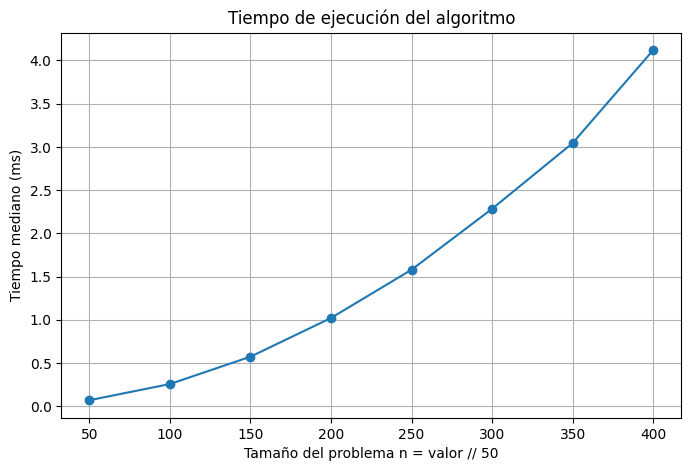

In [7]:

import time
import statistics
import matplotlib.pyplot as plt


def medir_tiempo(valor, repeticiones=9):
    # Ejecución de calentamiento.
    calcular_cambio(valor)

    mediciones = []

    for _ in range(repeticiones):
        inicio = time.perf_counter()

        calcular_cambio(valor)

        fin = time.perf_counter()

        mediciones.append((fin - inicio) * 1000)

    return statistics.median(mediciones)


valores = [2500, 5000, 7500, 10000, 12500, 15000, 17500, 20000]
tamanos = [valor // 50 for valor in valores]

tiempos = []

for valor in valores:
    tiempo = medir_tiempo(valor)
    tiempos.append(tiempo)

print("Valor".ljust(10), "n".ljust(8), "Tiempo mediano (ms)")
print("-" * 42)

for valor, n, tiempo in zip(valores, tamanos, tiempos):
    print(
        str(valor).ljust(10),
        str(n).ljust(8),
        f"{tiempo:.6f}"
    )


plt.figure(figsize=(8, 5))
plt.plot(tamanos, tiempos, marker="o")
plt.xlabel("Tamaño del problema n = valor // 50")
plt.ylabel("Tiempo mediano (ms)")
plt.title("Tiempo de ejecución del algoritmo")
plt.grid(True)
plt.show()



### Interpretación de la prueba de desempeño

La gráfica utiliza tiempos reales obtenidos al ejecutar el algoritmo.

Cuando `n` aumenta, el ciclo externo tiene más iteraciones y, además, el ciclo interno revisa una mayor cantidad de subproblemas anteriores.

Por ejemplo:

```text
n = 100  -> aproximadamente 5.050 recorridos internos
n = 200  -> aproximadamente 20.100 recorridos internos
n = 400  -> aproximadamente 80.200 recorridos internos
```

Al duplicar `n`, el número de recorridos internos aumenta aproximadamente cuatro veces. Este comportamiento corresponde al crecimiento cuadrático explicado en el análisis de complejidad.

Los tiempos exactos pueden cambiar dependiendo del computador, pero la tendencia de crecimiento debe aumentar de forma similar a \(n^2\).

---

## Conclusión

La solución utiliza programación dinámica porque guarda en `dp` los resultados de los subproblemas y los reutiliza para calcular valores mayores.

La implementación determina correctamente la cantidad mínima de monedas y permite comprobar su funcionamiento mediante pruebas automáticas.

La complejidad temporal es:

\[
O(n^2)
\]

porque para cada valor `i` se recorren todos los subproblemas anteriores.

La complejidad espacial es:

\[
O(n)
\]

porque la lista `dp` tiene `n + 1` posiciones.
